In [ ]:
import os, gc, json, time, resource
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import trimesh
import pysdf
import torch

from sdf_model import MultiResHashSDF, HashConfig

MESH_DIR   = Path('test_task_meshes')
MODELS_DIR = Path('models'); MODELS_DIR.mkdir(exist_ok=True)

RUN_TRAIN_ALL    = True 
RUN_EVAL_ALL     = True  
RUN_RETRAIN_HARD = False 
RUN_BENCH        = True 

DEVICE = torch.device('cpu')  

def mem_mb() -> float:
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return rss / (1024**2) if os.uname().sysname == 'Darwin' else rss / 1024

mesh_files = sorted(MESH_DIR.glob('*.obj'), key=lambda p: int(p.stem))
print(f'Found {len(mesh_files)} meshes  |  device: {DEVICE}  |  RSS: {mem_mb():.0f} MB')

Darwin
Found 50 meshes  |  device: cpu  |  RSS: 527 MB


## 1. Mesh I/O & normalization

In [2]:
def load_mesh(path: Path) -> trimesh.Trimesh:
    m = trimesh.load(path, force='mesh')
    if isinstance(m, trimesh.Scene):
        m = trimesh.util.concatenate([
            trimesh.Trimesh(vertices=g.vertices, faces=g.faces) for g in m.geometry.values()])
    return m

def normalize_mesh(m: trimesh.Trimesh, padding: float = 0.95) -> trimesh.Trimesh:
    """Center at origin, isotropically scale so the bbox sits in [-padding, padding]."""
    m = m.copy()
    center = (m.bounds[0] + m.bounds[1]) / 2.0
    m.apply_translation(-center)
    m.apply_scale(padding / np.abs(m.bounds).max())
    return m

print('mesh utilities defined.')

mesh utilities defined.


## 2. EDA — per-mesh stats


In [3]:
rows = []
for p in mesh_files:
    m = load_mesh(p)
    bbox = m.bounds; extents = bbox[1] - bbox[0]
    rows.append({
        'id': int(p.stem),
        'n_vertices': len(m.vertices),
        'n_faces': len(m.faces),
        'watertight': bool(m.is_watertight),
        'area': float(m.area),
        'volume': float(m.volume) if m.is_watertight else float('nan'),
        'max_extent': float(extents.max()),
        'volume_frac': float(m.volume) / (extents[0]*extents[1]*extents[2]) if m.is_watertight else float('nan'),
    })
    del m; gc.collect()

df = pd.DataFrame(rows).sort_values('id').reset_index(drop=True)
print(f'Watertight: {df["watertight"].sum()}/{len(df)}  |  RSS: {mem_mb():.0f} MB')
df.describe()

Watertight: 2/50  |  RSS: 447 MB


,id,n_vertices,n_faces,area,volume,max_extent,volume_frac
count,50.00000,50.000000,50.000000,50.000000,2.000000,5.000000e+01,2.000000
mean,24.50000,17191.020000,35025.600000,9.405252,0.089372,1.900000e+00,0.093065
std,14.57738,11604.010664,23854.216563,9.353230,0.009572,2.242989e-16,0.077118
min,0.00000,2130.000000,4266.000000,0.939274,0.082604,1.900000e+00,0.038535
25%,12.25000,8781.750000,17983.500000,2.844275,0.085988,1.900000e+00,0.065800
50%,24.50000,14888.500000,31209.000000,7.096477,0.089372,1.900000e+00,0.093065
75%,36.75000,25604.000000,52272.000000,11.900938,0.092756,1.900000e+00,0.120330
max,49.00000,54147.000000,109908.000000,45.353626,0.096140,1.900000e+00,0.147596


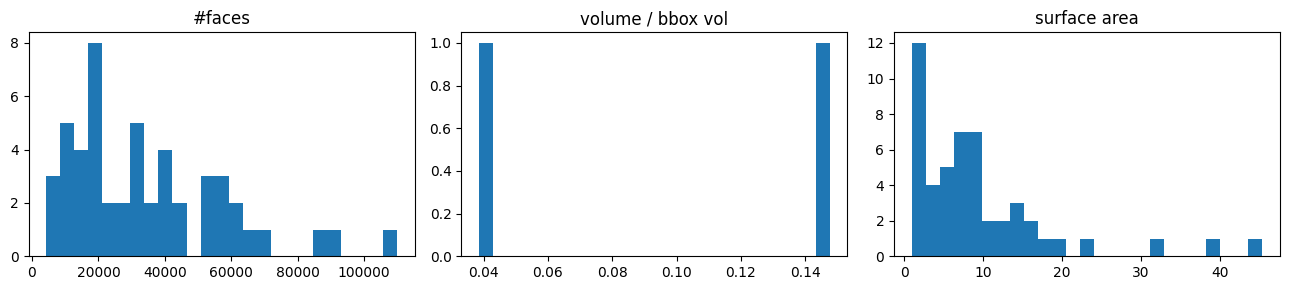

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
axes[0].hist(df['n_faces'], bins=25);     axes[0].set_title('#faces')
axes[1].hist(df['volume_frac'].dropna(), bins=25); axes[1].set_title('volume / bbox vol')
axes[2].hist(df['area'], bins=25);        axes[2].set_title('surface area')
plt.tight_layout(); plt.show()

## 3. Visualization — 6 normalized meshes

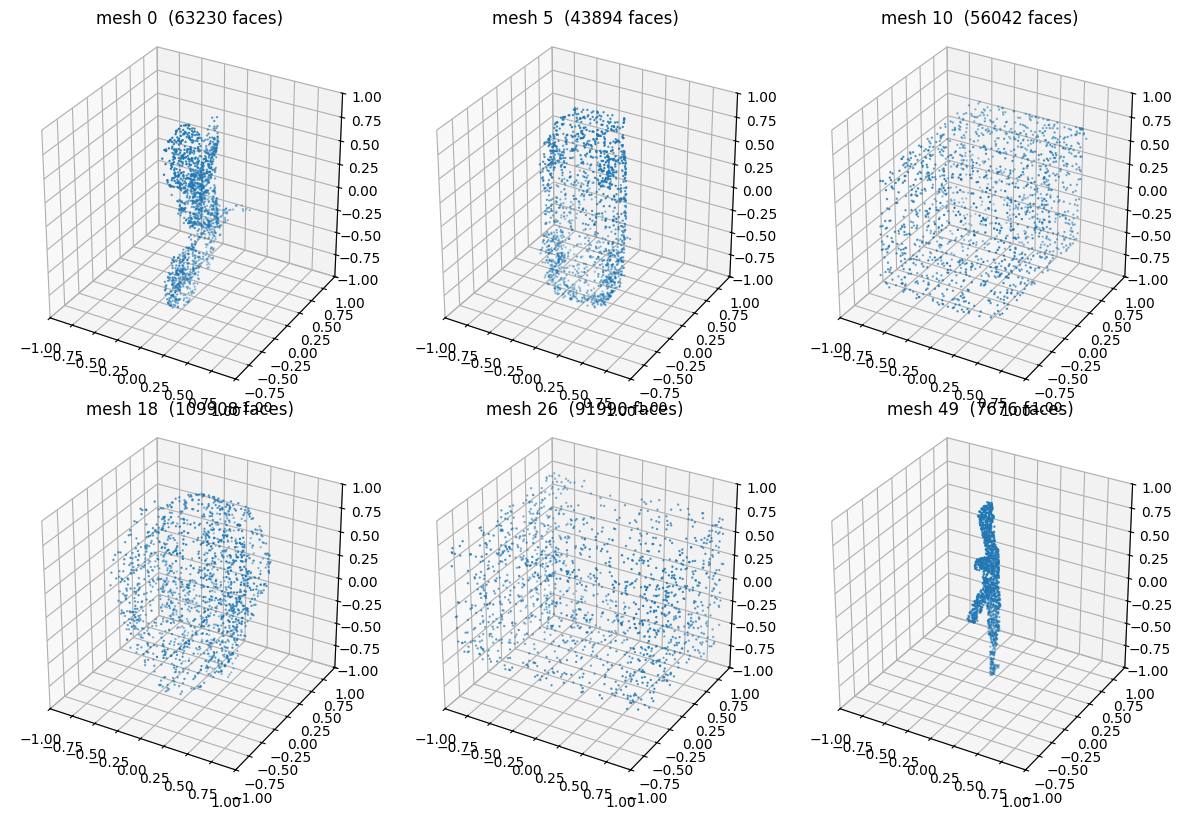

In [5]:
fig = plt.figure(figsize=(12, 8))
for i, mid in enumerate([0, 5, 10, 18, 26, 49]):
    m = normalize_mesh(load_mesh(MESH_DIR / f'{mid}.obj'))
    pts, _ = trimesh.sample.sample_surface(m, 1500)
    ax = fig.add_subplot(2, 3, i+1, projection='3d')
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=0.5)
    ax.set_title(f'mesh {mid}  ({len(m.faces)} faces)')
    ax.set_xlim(-1,1); ax.set_ylim(-1,1); ax.set_zlim(-1,1)
    ax.set_box_aspect((1,1,1))
    del m, pts; gc.collect()
plt.tight_layout(); plt.show()

## 4. Training

Each step:
1. Sample fresh surface points + perturbed (σ=1e-2 and σ=1e-3) + uniform bbox.
2. Compute GT SDF via pysdf.
3. L1 regression loss.

Eval set is fresh & independent (different RNG seed); Early-stop when both F1s clear 0.96.

In [ ]:
def compute_f1(pred: np.ndarray, gt_inside: np.ndarray) -> float:
    pred_inside = pred < 0
    tp = np.logical_and(pred_inside,  gt_inside).sum()
    fp = np.logical_and(pred_inside, ~gt_inside).sum()
    fn = np.logical_and(~pred_inside, gt_inside).sum()
    if tp + fp + fn == 0:
        return 1.0
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    return 0.0 if prec + rec == 0 else float(2 * prec * rec / (prec + rec))

def train_one_mesh(mid: int,
                   n_iters: int = 2500,
                   cfg: HashConfig = None,
                   lr: float = 5e-3,
                   per_step=dict(surface=512, near_1e2=4000, near_1e3=2000, uniform=1024),
                   eval_every: int = 250,
                   early_stop_f1: float = 0.96,
                   verbose: bool = False):
    """Online-resampling trainer for one mesh. Returns (model, history)."""
    mesh = normalize_mesh(load_mesh(MESH_DIR / f'{mid}.obj'))
    sdf_fn = pysdf.SDF(mesh.vertices, mesh.faces)

    rng_e = np.random.default_rng(999 + mid); n_e = 10_000
    base_e = trimesh.sample.sample_surface(mesh, n_e)[0]
    eval_pts = np.concatenate([
        (base_e + rng_e.normal(0, 1e-2, (n_e, 3))).astype(np.float32),
        rng_e.uniform(-1, 1, (n_e, 3)).astype(np.float32)], axis=0)
    eval_sdf = (-sdf_fn(eval_pts)).astype(np.float32)
    eval_gi_near = eval_sdf[:n_e] < 0
    eval_gi_unif = eval_sdf[n_e:] < 0
    eval_pts_t = torch.from_numpy(eval_pts).to(DEVICE)

    torch.manual_seed(mid)
    model = MultiResHashSDF(cfg if cfg is not None else HashConfig()).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    rng = np.random.default_rng(42 + mid)
    Q = per_step; history = []
    for it in range(n_iters):
        base = trimesh.sample.sample_surface(mesh, Q['surface'] + Q['near_1e2'] + Q['near_1e3'])[0]
        p_s  = base[:Q['surface']]
        p_n2 = base[Q['surface']:Q['surface']+Q['near_1e2']] + rng.normal(0, 1e-2, (Q['near_1e2'], 3))
        p_n3 = base[-Q['near_1e3']:] + rng.normal(0, 1e-3, (Q['near_1e3'], 3))
        p_u  = rng.uniform(-1, 1, (Q['uniform'], 3))
        pts_np = np.concatenate([p_s, p_n2, p_n3, p_u], axis=0).astype(np.float32)
        sdf_np = (-sdf_fn(pts_np)).astype(np.float32)
        good = np.abs(sdf_np) < 5.0
        pts_np, sdf_np = pts_np[good], sdf_np[good]

        p = torch.from_numpy(pts_np).to(DEVICE); s = torch.from_numpy(sdf_np).to(DEVICE)
        pred = model(p)
        loss = (pred - s).abs().mean()
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()

        if (it + 1) % eval_every == 0 or it == n_iters - 1:
            with torch.no_grad(): pe = model(eval_pts_t).cpu().numpy()
            f1n = compute_f1(pe[:n_e], eval_gi_near)
            f1u = compute_f1(pe[n_e:], eval_gi_unif)
            history.append({'it': it+1, 'loss': float(loss), 'f1_near': f1n, 'f1_unif': f1u})
            if verbose:
                print(f'  it={it+1:>4}  loss={float(loss):.4f}  f1_near={f1n:.3f}  f1_unif={f1u:.3f}')
            if f1n >= early_stop_f1 and f1u >= early_stop_f1:
                if verbose: print(f'  early stop at it={it+1}')
                break

    return model, history

print('train_one_mesh defined.')

train_one_mesh defined.


### Train all 50 meshes

In [8]:
if RUN_TRAIN_ALL:
    log = []; grand_t0 = time.time()
    for p in mesh_files:
        mid = int(p.stem)
        out = MODELS_DIR / f'{mid}.npz'
        if out.exists():
            print(f'[{mid:>2}] cached — skipping'); continue
        t0 = time.time()
        model, history = train_one_mesh(mid, verbose=False)
        model.export_npz(out)
        size_kb = out.stat().st_size / 1024
        last = history[-1] if history else {'f1_near': float('nan'), 'f1_unif': float('nan')}
        print(f'[{mid:>2}] {time.time()-t0:5.1f}s  size={size_kb:6.1f} KB  '
              f'f1_near={last["f1_near"]:.3f}  f1_unif={last["f1_unif"]:.3f}  RSS={mem_mb():.0f} MB')
        log.append({'id': mid, **last, 'size_kb': size_kb})
        del model; gc.collect()
    pd.DataFrame(log).to_csv(MODELS_DIR / 'train_log.csv', index=False)
    print(f'\nTotal training time: {(time.time()-grand_t0)/60:.1f} min')
else:
    print('Full training skipped. Set RUN_TRAIN_ALL = True to enable.')

[ 0] cached — skipping
[ 1] cached — skipping
[ 2] cached — skipping
[ 3] cached — skipping
[ 4] cached — skipping
[ 5] cached — skipping
[ 6] cached — skipping
[ 7] cached — skipping
[ 8] cached — skipping
[ 9] cached — skipping
[10] cached — skipping
[11] cached — skipping
[12] cached — skipping
[13] cached — skipping
[14] cached — skipping
[15] cached — skipping
[16] cached — skipping
[17] cached — skipping
[18] cached — skipping
[19] cached — skipping
[20] cached — skipping
[21] cached — skipping
[22] cached — skipping
[23] cached — skipping
[24] cached — skipping
[25] cached — skipping
[26] cached — skipping
[27] cached — skipping
[28] cached — skipping
[29] cached — skipping
[30] cached — skipping
[31] cached — skipping
[32] cached — skipping
[33] cached — skipping
[34] cached — skipping
[35] cached — skipping
[36] cached — skipping
[37] cached — skipping
[38] cached — skipping
[39] cached — skipping
[40] cached — skipping
[41] cached — skipping
[42] cached — skipping
[43] cached

## 5. Evaluation — F1 across all 50 meshes 

In [9]:
if RUN_EVAL_ALL:
    rows = []
    for p in mesh_files:
        mid = int(p.stem)
        npz = MODELS_DIR / f'{mid}.npz'
        if not npz.exists():
            print(f'[{mid:>2}] no model — skipping'); continue
        mesh = normalize_mesh(load_mesh(MESH_DIR / f'{mid}.obj'))
        sdf_fn = pysdf.SDF(mesh.vertices, mesh.faces)
        rng_e = np.random.default_rng(7777 + mid); n_e = 10_000
        base_e = trimesh.sample.sample_surface(mesh, n_e)[0]
        eval_pts = np.concatenate([
            (base_e + rng_e.normal(0, 1e-2, (n_e, 3))).astype(np.float32),
            rng_e.uniform(-1, 1, (n_e, 3)).astype(np.float32)])
        eval_sdf = (-sdf_fn(eval_pts)).astype(np.float32)

        model = MultiResHashSDF.from_npz(npz).to(DEVICE).eval()
        with torch.no_grad():
            pe = model(torch.from_numpy(eval_pts).to(DEVICE)).cpu().numpy()
        f1n = compute_f1(pe[:n_e], eval_sdf[:n_e] < 0)
        f1u = compute_f1(pe[n_e:], eval_sdf[n_e:] < 0)
        size_kb = npz.stat().st_size / 1024
        rows.append({'id': mid, 'f1_near': f1n, 'f1_unif': f1u, 'size_kb': size_kb})
        del mesh, model, sdf_fn; gc.collect()
    eval_df = pd.DataFrame(rows).sort_values('id').reset_index(drop=True)
    print('\n=== Aggregate ===')
    print(f'F1_near   mean={eval_df["f1_near"].mean():.3f}   min={eval_df["f1_near"].min():.3f}   max={eval_df["f1_near"].max():.3f}   target>0.90')
    print(f'F1_unif   mean={eval_df["f1_unif"].mean():.3f}   min={eval_df["f1_unif"].min():.3f}   max={eval_df["f1_unif"].max():.3f}   target>0.95')
    print(f'size      mean={eval_df["size_kb"].mean():.1f} KB  max={eval_df["size_kb"].max():.1f} KB   target<1024 KB')
    eval_df.to_csv(MODELS_DIR / 'eval.csv', index=False)
    eval_df.head(10)
else:
    print('Eval skipped. Set RUN_EVAL_ALL = True to enable.')


=== Aggregate ===
F1_near   mean=0.900   min=0.108   max=0.975   target>0.90
F1_unif   mean=0.949   min=0.333   max=1.000   target>0.95
size      mean=333.4 KB  max=470.4 KB   target<1024 KB


## 6. Retrain hard meshes 

In [ ]:
if RUN_RETRAIN_HARD:
    eval_df = pd.read_csv(MODELS_DIR / 'eval.csv')
    F1_NEAR_TGT, F1_UNIF_TGT = 0.92, 0.96
    hard = eval_df[(eval_df['f1_near'] < F1_NEAR_TGT) | (eval_df['f1_unif'] < F1_UNIF_TGT)]
    print(f'retraining {len(hard)} meshes: {hard["id"].tolist()}')
    big_cfg = HashConfig(n_levels=8, n_features=2, log2_table_size=14,
                         base_resolution=8, finest_resolution=128, hidden=16)
    log = []; t0_all = time.time()
    for mid in hard['id'].tolist():
        t0 = time.time()
        model, history = train_one_mesh(mid, n_iters=5000, cfg=big_cfg, verbose=False)
        out = MODELS_DIR / f'{mid}.npz'
        model.export_npz(out)
        last = history[-1] if history else {'f1_near': float('nan'), 'f1_unif': float('nan')}
        size_kb = out.stat().st_size / 1024
        print(f'[{mid:>2}] {time.time()-t0:5.1f}s  size={size_kb:6.1f} KB  '
              f'f1_near={last["f1_near"]:.3f}  f1_unif={last["f1_unif"]:.3f}')
        log.append({'id': mid, **last, 'size_kb': size_kb})
        del model; gc.collect()
    print(f'\nRetrained {len(log)} meshes in {(time.time()-t0_all)/60:.1f} min')
else:
    print('Retrain skipped. Set RUN_RETRAIN_HARD = True to enable.')


Retrain skipped. Set RUN_RETRAIN_HARD = True to enable.


## 7. Inference benchmarks

Loads each trained `.npz` via the numba inference path ([sdf_inference.py](sdf_inference.py)) and measures:

- **Parity** against the torch reference on 1 000 random points (target: max|diff| < 1e-3).
- **Single-point latency** measured in a compiled loop (`_forward_loop_bench`) so the per-call Python overhead is excluded.
- **Batched throughput** at B=1 000, 10 000, 100 000.
- **Model file size** for each mesh.


In [ ]:
if RUN_BENCH:
    from sdf_inference import SDFInference
    rng = np.random.default_rng(123)
    rows = []
    for p in mesh_files:
        mid = int(p.stem)
        npz = MODELS_DIR / f'{mid}.npz'
        if not npz.exists(): continue
        nb = SDFInference(npz); nb.warmup()

        torch_m = MultiResHashSDF.from_npz(npz).eval()
        pts = rng.uniform(-1, 1, (1000, 3)).astype(np.float32)
        with torch.no_grad():
            tp = torch_m(torch.from_numpy(pts)).numpy()
        npp = nb(pts)
        max_diff = float(np.abs(tp - npp).max())

        ns_single = nb.bench_single_point(100_000)

        bench = {}
        for B in [1000, 10_000, 100_000]:
            bp = rng.uniform(-1, 1, (B, 3)).astype(np.float32)
            t = []
            for _ in range(20):
                t0 = time.perf_counter(); _ = nb(bp); t.append(time.perf_counter() - t0)
            bench[B] = float(np.median(t) * 1e3)  # ms

        rows.append({'id': mid,
                     'parity_max_diff': max_diff,
                     'size_kb': npz.stat().st_size / 1024,
                     'ns_single': ns_single,
                     'ms_1k': bench[1000],
                     'ms_10k': bench[10_000],
                     'ms_100k': bench[100_000]})
        del torch_m, nb; gc.collect()

    bench_df = pd.DataFrame(rows).sort_values('id').reset_index(drop=True)
    print('\n=== Aggregate ===')
    print(f'parity_max_diff   max={bench_df["parity_max_diff"].max():.2e}   target<1e-3')
    print(f'size_kb           mean={bench_df["size_kb"].mean():.0f}  max={bench_df["size_kb"].max():.0f}   target<1024')
    print(f'ns_single         mean={bench_df["ns_single"].mean():.0f}  max={bench_df["ns_single"].max():.0f}   target: few ns')
    print(f'ms_1k    (1 k pts)  mean={bench_df["ms_1k"].mean():.3f}  max={bench_df["ms_1k"].max():.3f}   target: few ms')
    print(f'ms_10k   (10k pts) mean={bench_df["ms_10k"].mean():.3f}  max={bench_df["ms_10k"].max():.3f}')
    print(f'ms_100k (100k pts) mean={bench_df["ms_100k"].mean():.3f}  max={bench_df["ms_100k"].max():.3f}')
    bench_df.to_csv(MODELS_DIR / 'bench.csv', index=False)
    bench_df.head(10)
else:
    print('Bench skipped. Set RUN_BENCH = True to enable.')



=== Aggregate ===
parity_max_diff   max=4.80e-05   target<1e-3
size_kb           mean=333  max=470   target<1024
ns_single         mean=102  max=103   target: few ns
ms_1k    (1 k pts)  mean=0.103  max=0.118   target: few ms
ms_10k   (10k pts) mean=0.337  max=0.372
ms_100k (100k pts) mean=2.650  max=2.931
